# Modeling KBest - KNN - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)


## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [1]:
import pandas as pd
from sklearn.model_selection import cross_validate,GridSearchCV,StratifiedKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

knn =  KNeighborsClassifier()

xtrain_KB = pd.read_csv("xtrain_KB.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=knn,X=xtrain_KB,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)



,fit_time,score_time,test_score,train_score
0,0.036224,0.082512,0.698972,0.777097
1,0.024354,0.076625,0.682667,0.777577
2,0.024321,0.083245,0.681153,0.784064
3,0.024257,0.075881,0.692207,0.780086
4,0.024956,0.068448,0.672720,0.784789


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  0.780722711154999
Mean validation score 0.6855436552541045


Le modèle KNN avec ses paramètres par défaut obtient un F1-macro moyen d’environ **0,686** en validation croisée, contre **0,781** sur l’entraînement.

L’écart entraînement–validation est donc d’environ **0,095**, ce qui indique un surapprentissage modéré.

Cette baseline constitue un point de référence pour mesurer l’effet de l’optimisation de `n_neighbors`, de la pondération des voisins et de la métrique de distance.

## 3. Hyperparameter Tuning

In [3]:
settings_grid = {
   "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p":[1,2]
}

grid_search = GridSearchCV(estimator=knn,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    X=xtrain_KB,
    y=ytrain
)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,15


In [4]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)

print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best validation F1: 0.7023543212386799
Mean train F1: 1.0
Std validation F1: 0.010549582464178536


L’optimisation sélectionne `n_neighbors=15`, `p=1` et `weights="distance"`.

Le F1-macro moyen de validation passe d’environ **0,686 à 0,702**, soit une amélioration d’environ **0,017**. En revanche, le F1-macro moyen d’entraînement atteint **1,000**.

L’écart entraînement–validation passe donc d’environ **0,095 à 0,298**. Le tuning améliore légèrement la performance de validation, mais au prix d’un surapprentissage nettement plus important.

Le choix de `p=1` correspond à la distance de Manhattan. La pondération par la distance donne davantage d’importance aux voisins les plus proches, ce qui peut expliquer la capacité du modèle à mémoriser très fortement les observations d’entraînement.

L’écart-type du F1-macro de validation est d’environ **0,011**, ce qui indique une variabilité limitée entre les folds.

## 4. Final Evaluation

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_KB = pd.read_csv("xtest_KB.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_KB)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7370622059592263
Precision macro : 0.7006884098222922
Recall macro : 0.7032953682004864
F1 macro : 0.6987678385705237


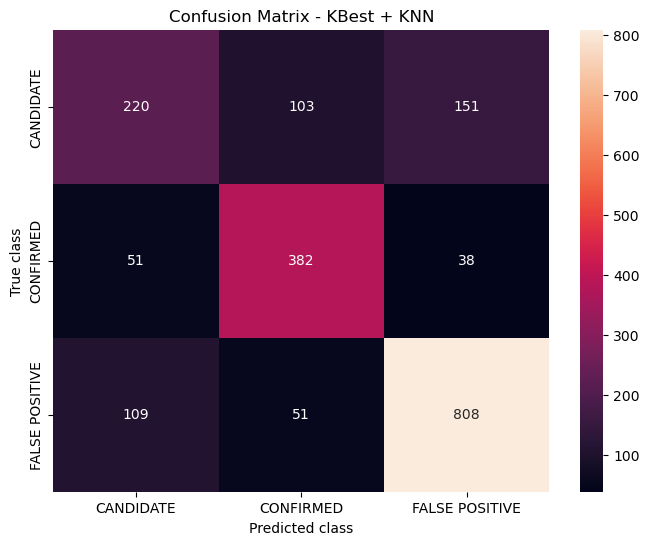

In [6]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - KBest + KNN")

plt.show()

Sur le jeu de test indépendant, le KNN optimisé obtient :

- **Accuracy : 0,7371**
- **Precision macro : 0,7007**
- **Recall macro : 0,7033**
- **F1 macro : 0,6988**

Le F1-macro sur le test reste proche du score obtenu en validation croisée (**0,7024**), ce qui montre que la performance de généralisation est cohérente entre validation et test.

Cependant, le F1 d’entraînement égal à **1,000** montre que le modèle mémorise fortement le train set. L’amélioration obtenue par le tuning doit donc être interprétée avec prudence : la performance de validation progresse, mais le surapprentissage augmente fortement.

## 5. Model Limits

La difficulté à prédire la classe CANDIDATE pourrait ne pas être uniquement liée aux limites du modèle. Un candidat KOI possède par définition un statut encore incertain et peut présenter des caractéristiques proches aussi bien des objets confirmés que des faux positifs. Cette ambiguïté intrinsèque pourrait expliquer une partie des confusions observées.